# 解码策略

> 训练时，模型看到的是正确答案的前文（Teacher Forcing），所有位置可以并行计算。推理时没有正确答案了——模型必须先生成一个 token，把它拼回输入，再生成下一个。
>
> 这一节实现自回归生成的核心策略：greedy decoding、temperature sampling、top-k/top-p 截断、beam search。先训练一个小模型，让每种策略的效果都能在输出中直接看到。

自回归生成（Autoregressive Generation）是当前所有 LLM 生成文本的基本方式。模型先生成第一个 token，拼到输入里，再生成第二个，再拼回去，如此循环。

每次只生成一个 token，但每次都要把累积的序列重新算一遍 Attention。这个串行特性是 LLM 推理慢的根本原因，也是模型能根据已生成内容动态调整输出的关键。

## 1. 推理和训练的根本区别

```
训练:  有答案 → 所有位置并行算 loss → Teacher Forcing
推理:  没答案 → 只能逐个 token 串行生成 → Autoregressive
```

自回归的意思：用自己生成的输出，作为下一步的输入。

```
Step 1: 输入 [BOS]           → 模型预测 → 我
Step 2: 输入 [BOS, 我]       → 模型预测 → 爱
Step 3: 输入 [BOS, 我, 爱]   → 模型预测 → 你
Step 4: 输入 [BOS, 我, 爱, 你] → 模型预测 → EOS → 停止
```

像贪吃蛇——吃自己的尾巴，越吃越长。

## 2. 训练一个能看到效果的模型

为了让 temperature、top-k 等策略的效果真实可见，我们需要一个模型：它的输出不是完全确定的（有概率分散），也不是完全随机的。用一段有规律但不唯一的文本作为训练数据：给出几个词，后面的接法有多个合理选项。

这里用一个「多元模式」：每个位置有 2-3 个合理的后继，模型对不同后继有不同的概率。这样 temperature 的效果就能在输出中体现出来。

In [1]:
import torch
import torch.nn as nn

class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(64, d_model)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads,
                dim_feedforward=4*d_model, batch_first=True, activation='relu')
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch, seq = x.shape
        pos = torch.arange(seq, device=x.device).unsqueeze(0).expand(batch, -1)
        h = self.token_emb(x) + self.pos_emb(pos)
        mask = nn.Transformer.generate_square_subsequent_mask(seq, device=x.device)
        for block in self.blocks:
            h = block(h, src_mask=mask, is_causal=True)
        return self.lm_head(h)

VOCAB = 16

def make_multi_path_data(n=800, seq_len=10):
    # 多条路径：从 token 1 出发，有两条可能的路径
    # 路径 A: 1→2→3→4→5→6→7→8→1...  (70%)
    # 路径 B: 1→2→9→10→11→12→7→8→1... (30%)
    # 分叉点在位置 2：3 或 9
    data = []
    for i in range(n):
        path = i % 10  # 约 70% 走 A
        seq = [1, 2]
        if path < 7:
            seq.extend([3, 4, 5, 6])
        else:
            seq.extend([9, 10, 11, 12])
        seq.extend([7, 8])
        data.append(seq[:seq_len])
    return torch.tensor(data)

train_data = make_multi_path_data()
print(f'训练数据: {train_data.shape}')
print(f'路径 A 样本: {train_data[0].tolist()}')
print(f'路径 B 样本: {train_data[7].tolist()}')
print(f'分叉点: 位置2 → token 3 (70%) 或 token 9 (30%)')


训练数据: torch.Size([800, 8])
路径 A 样本: [1, 2, 3, 4, 5, 6, 7, 8]
路径 B 样本: [1, 2, 9, 10, 11, 12, 7, 8]
分叉点: 位置2 → token 3 (70%) 或 token 9 (30%)


In [2]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(64, d_model)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads,
                dim_feedforward=4*d_model, batch_first=True, activation='relu')
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch, seq = x.shape
        pos = torch.arange(seq, device=x.device).unsqueeze(0).expand(batch, -1)
        h = self.token_emb(x) + self.pos_emb(pos)
        mask = nn.Transformer.generate_square_subsequent_mask(seq, device=x.device)
        for block in self.blocks:
            h = block(h, src_mask=mask, is_causal=True)
        return self.lm_head(h)

VOCAB = 16

def make_multi_path_data(n=800, seq_len=10):
    # 多条路径：从 token 1 出发，有两条可能的路径
    # 路径 A: 1→2→3→4→5→6→7→8→1...  (70%)
    # 路径 B: 1→2→9→10→11→12→7→8→1... (30%)
    # 分叉点在位置 2：3 或 9
    data = []
    for i in range(n):
        path = i % 10  # 约 70% 走 A
        seq = [1, 2]
        if path < 7:
            seq.extend([3, 4, 5, 6])
        else:
            seq.extend([9, 10, 11, 12])
        seq.extend([7, 8])
        data.append(seq[:seq_len])
    return torch.tensor(data)

train_data = make_multi_path_data()
print(f'训练数据: {train_data.shape}')
print(f'路径 A 样本: {train_data[0].tolist()}')
print(f'路径 B 样本: {train_data[7].tolist()}')
print(f'分叉点: 位置2 → token 3 (70%) 或 token 9 (30%)')


训练数据: torch.Size([800, 8])
路径 A 样本: [1, 2, 3, 4, 5, 6, 7, 8]
路径 B 样本: [1, 2, 9, 10, 11, 12, 7, 8]
分叉点: 位置2 → token 3 (70%) 或 token 9 (30%)


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
model = SimpleGPT(VOCAB)

# 训练目标：给前 9 个 token，预测每个位置的下一个
# 输入 train_data[:, :-1]，目标 train_data[:, 1:]（错位一格）
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print('开始训练...')
for epoch in range(100):
    inputs = train_data[:, :-1]
    targets = train_data[:, 1:]
    logits = model(inputs)
    loss = loss_fn(logits.reshape(-1, VOCAB), targets.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f'  epoch {epoch+1:3d}, loss = {loss.item():.4f}')

print(f'\n训练完成，最终 loss = {loss.item():.4f}')


开始训练...


  epoch  20, loss = 0.7551


  epoch  40, loss = 0.3908


  epoch  60, loss = 0.2707


  epoch  80, loss = 0.2104


  epoch 100, loss = 0.1764

训练完成，最终 loss = 0.1764


In [4]:
# 查看模型在分叉点的概率分布
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    # 输入 [1, 2]，看位置2的预测
    logits = model(torch.tensor([[1, 2]]))
    probs = F.softmax(logits[0, -1, :], dim=-1)

print('输入 [1, 2] 后，模型对下一个 token 的概率分布:')
for tok_id in range(VOCAB):
    p = probs[tok_id].item()
    if p > 0.01:
        bar = '█' * int(p * 50)
        print(f'  token {tok_id:2d}: {p:.3f} {bar}')

print(f'\ntoken 3 (路径A): {probs[3].item():.1%}')
print(f'token 9 (路径B): {probs[9].item():.1%}')
print(f'\n模型学到了两条路径的概率分布！后续 temperature 调整就能改变走哪条路。')


输入 [1, 2] 后，模型对下一个 token 的概率分布:
  token  3: 0.657 ████████████████████████████████
  token  7: 0.011 
  token  9: 0.267 █████████████

token 3 (路径A): 65.7%
token 9 (路径B): 26.7%

模型学到了两条路径的概率分布！后续 temperature 调整就能改变走哪条路。


## 3. Greedy Decoding

每一步选概率最高的 token。优点是确定性和速度快——同样输入总是同样输出。缺点是一旦选了某个 token，就永远失去了探索其他分支的机会。

In [5]:
import torch

def generate_greedy(model, input_ids, max_new_tokens=20, eos_id=None):
    model.eval()
    generated = input_ids.clone()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(generated)
            next_logits = logits[0, -1, :]
            next_token = torch.argmax(next_logits, dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            if eos_id is not None and next_token.item() == eos_id:
                break
    return generated

prompt = torch.tensor([[1, 2]])
result = generate_greedy(model, prompt, max_new_tokens=12)
print(f'Greedy 结果: {result[0].tolist()}')
print(f'\nGreedy 总是选概率最高的，所以每次运行都走路径 A (token 3)。')
print(f'即使路径 B 也有 30% 的概率，Greedy 永远不会选它。')


Greedy 结果: [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8, 7, 10]

Greedy 总是选概率最高的，所以每次运行都走路径 A (token 3)。
即使路径 B 也有 30% 的概率，Greedy 永远不会选它。


## 4. Temperature：控制随机性

Temperature 通过缩放 logits 来控制概率分布的形状：

```
probability = softmax(logits / temperature)

temperature = 0.1 → 分布极尖 → 几乎 greedy
temperature = 1.0 → 原始分布
temperature = 2.0 → 分布更平 → 更随机
```

In [6]:
# Temperature 对分叉点的影响
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    logits = model(torch.tensor([[1, 2]]))[0, -1, :]

print('=== Temperature 对分叉点概率的影响 ===')
print(f'{"Temperature":>12}  {"P(token 3)":>10}  {"P(token 9)":>10}  {"比 3/9":>8}')
print('-' * 48)
for T in [0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 5.0]:
    probs = F.softmax(logits / T, dim=-1)
    p3 = probs[3].item()
    p9 = probs[9].item()
    ratio = p3 / p9 if p9 > 0 else float('inf')
    print(f'{T:>12.1f}  {p3:>10.3f}  {p9:>10.3f}  {ratio:>8.1f}')

print(f'\n低温: token 3 几乎 100%，相当于 greedy')
print(f'高温: token 3 和 9 的差距缩小，模型更可能探索路径 B')


=== Temperature 对分叉点概率的影响 ===
 Temperature  P(token 3)  P(token 9)     比 3/9
------------------------------------------------
         0.1       1.000       0.000    8060.7
         0.3       0.952       0.048      20.1
         0.5       0.857       0.142       6.0
         1.0       0.657       0.267       2.5
         1.5       0.476       0.261       1.8
         2.0       0.349       0.223       1.6
         5.0       0.141       0.118       1.2

低温: token 3 几乎 100%，相当于 greedy
高温: token 3 和 9 的差距缩小，模型更可能探索路径 B


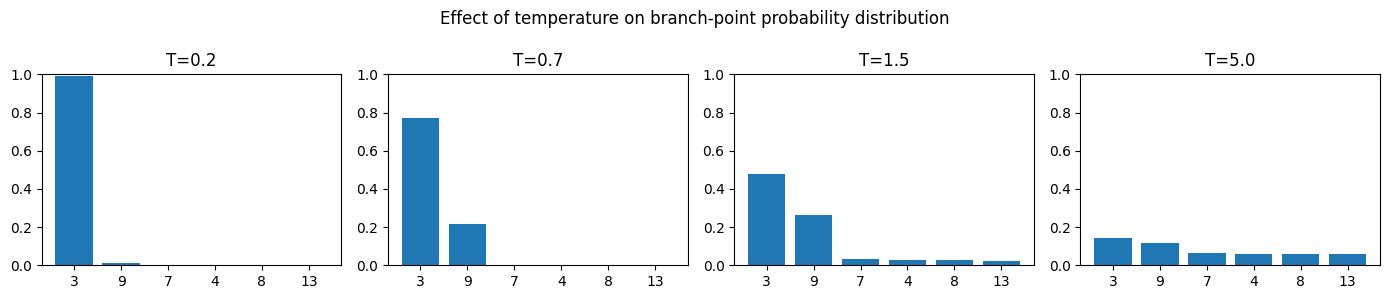

In [7]:
# 可视化
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
example_logits = logits.clone()
for ax, T in zip(axes, [0.2, 0.7, 1.5, 5.0]):
    probs = F.softmax(example_logits / T, dim=-1)
    top_k_probs, top_k_idx = torch.topk(probs, 6)
    ax.bar(range(6), top_k_probs.numpy())
    ax.set_xticks(range(6))
    ax.set_xticklabels([str(i.item()) for i in top_k_idx])
    ax.set_title(f'T={T}')
    ax.set_ylim(0, 1)
plt.suptitle('Effect of temperature on branch-point probability distribution')
plt.tight_layout()
plt.show()


In [8]:
# 不同 temperature 的实际生成结果
import torch
import torch.nn.functional as F

print('同一 prompt [1, 2]，不同 temperature 的生成结果:')
print()

for T in [0.1, 0.5, 1.0, 1.5, 2.0]:
    results = []
    for seed in range(5):
        torch.manual_seed(seed)
        generated = torch.tensor([[1, 2]])
        model.eval()
        with torch.no_grad():
            for _ in range(12):
                logits = model(generated)[0, -1, :] / T
                probs = F.softmax(logits, dim=-1)
                token = torch.multinomial(probs, 1).unsqueeze(0)
                generated = torch.cat([generated, token], dim=1)
        results.append(generated[0, 2:6].tolist())  # 看分叉点的选择
    paths = ['A' if r[0] == 3 else 'B' for r in results]
    print(f'T={T:.1f}: {results}  路径: {paths}')

print(f'\n低温: 几乎全走路径A')
print(f'高温: 开始出现路径B，多样性增加')


同一 prompt [1, 2]，不同 temperature 的生成结果:



T=0.1: [[3, 4, 5, 6], [3, 4, 5, 6], [3, 4, 5, 6], [3, 4, 5, 6], [3, 4, 5, 6]]  路径: ['A', 'A', 'A', 'A', 'A']


T=0.5: [[9, 10, 11, 12], [3, 4, 5, 6], [3, 4, 5, 6], [3, 4, 5, 6], [3, 4, 5, 6]]  路径: ['B', 'A', 'A', 'A', 'A']


T=1.0: [[9, 10, 11, 10], [3, 4, 5, 6], [3, 4, 5, 6], [3, 4, 5, 6], [13, 4, 5, 6]]  路径: ['B', 'A', 'A', 'A', 'B']


T=1.5: [[9, 10, 11, 10], [3, 4, 5, 6], [3, 11, 9, 6], [3, 4, 0, 14], [13, 11, 12, 5]]  路径: ['B', 'A', 'A', 'A', 'B']


T=2.0: [[9, 10, 11, 10], [3, 10, 11, 12], [3, 11, 9, 6], [3, 15, 0, 14], [13, 11, 12, 5]]  路径: ['B', 'A', 'A', 'A', 'B']

低温: 几乎全走路径A
高温: 开始出现路径B，多样性增加


## 5. 采样截断：Top-k 和 Top-p

第 4 节看到，温度只能改变概率分布的尖锐程度，并不能把任何 token 的概率压到 0。即使温度很低，词表中那些几乎不可能出现的 token——训练时从未见过的编号、与上下文毫无关联的符号——依然保留着非零概率。

温度一高，问题就更明显：分布被压平之后，大量尾部 token 的概率都被抬上来。直接从全词表 multinomial 采样（这种做法叫 Pure Sampling，纯采样），很容易抽到这些不应该出现的词。下面先在 SimpleGPT 上看到这个问题，再依次引入 Top-k 和 Top-p 两种截断方案。


In [9]:
import torch
import torch.nn.functional as F

# Pure Sampling：直接从全词表 softmax 采样，不做任何截断
def pure_sampling(model, input_ids, max_new=6, temperature=1.0, seed=0):
    torch.manual_seed(seed)
    generated = input_ids.clone()
    model.eval()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    return generated

# 先看 [1, 2] 之后下一步的概率分布
model.eval()
with torch.no_grad():
    probs_at_branch = F.softmax(model(torch.tensor([[1, 2]]))[0, -1, :], dim=-1)

print('输入 [1, 2] 后，下一步每个 token 的概率（vocab=16）:')
for tid in range(VOCAB):
    p = probs_at_branch[tid].item()
    flag = ' ← 主候选' if p > 0.1 else ''
    print(f'  token {tid:2d}: {p:.4f}{flag}')

low_prob_count = (probs_at_branch < 0.01).sum().item()
print(f'\n概率低于 1% 的 token 数: {low_prob_count} / {VOCAB}')
print('这些"几乎不可能"的 token 在 Pure Sampling 下仍可能被抽到')

# 同一 prompt 跑 10 次 Pure Sampling，故意拉平分布看会不会出现非路径 token
print('\n=== Pure Sampling 跑 10 次（temperature=1.5，分布被拉平）===')
valid_path_tokens = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
for seed in range(10):
    r = pure_sampling(model, torch.tensor([[1, 2]]), max_new=6, temperature=1.5, seed=seed)
    seq = r[0].tolist()
    has_garbage = any(t not in valid_path_tokens for t in seq[2:])
    flag = ' ⚠ 出现路径外 token' if has_garbage else ''
    print(f'  seed={seed}: {seq}{flag}')


输入 [1, 2] 后，下一步每个 token 的概率（vocab=16）:
  token  0: 0.0026
  token  1: 0.0029
  token  2: 0.0062
  token  3: 0.6570 ← 主候选
  token  4: 0.0099
  token  5: 0.0055
  token  6: 0.0023
  token  7: 0.0106
  token  8: 0.0095
  token  9: 0.2672 ← 主候选
  token 10: 0.0051
  token 11: 0.0021
  token 12: 0.0046
  token 13: 0.0077
  token 14: 0.0038
  token 15: 0.0030

概率低于 1% 的 token 数: 13 / 16
这些"几乎不可能"的 token 在 Pure Sampling 下仍可能被抽到

=== Pure Sampling 跑 10 次（temperature=1.5，分布被拉平）===


  seed=0: [1, 2, 9, 10, 11, 10, 10, 13] ⚠ 出现路径外 token


  seed=1: [1, 2, 3, 4, 5, 6, 7, 0] ⚠ 出现路径外 token


  seed=2: [1, 2, 3, 11, 9, 6, 7, 4]


  seed=3: [1, 2, 3, 4, 0, 14, 2, 5] ⚠ 出现路径外 token


...

  seed=5: [1, 2, 3, 4, 5, 6, 7, 8]


  seed=6: [1, 2, 3, 4, 5, 12, 7, 11]


  seed=7: [1, 2, 13, 0, 5, 2, 7, 8] ⚠ 出现路径外 token


  seed=8: [1, 2, 3, 0, 5, 6, 7, 14] ⚠ 出现路径外 token


  seed=9: [1, 2, 3, 4, 11, 12, 7, 8]


### 5.1 Top-k：固定候选数量

最直接的截断办法是 Top-k：不管分布长什么样，只保留概率最高的 k 个 token，其余全部置为 0，再在这 k 个里重新归一化采样。

具体到当前的例子，输入 [1, 2] 之后取 k=2。从上面的概率表里挑出最高的两个：token 3 和 token 9。其他 14 个 token 全部置零，剩下的两个重新归一化后概率几乎不变：

```
P(token 3 | top-2) ≈ 0.66 / (0.66 + 0.27) = 0.71
P(token 9 | top-2) ≈ 0.27 / (0.66 + 0.27) = 0.29
```

k=2 在当前 prompt 下等同于"只在两条路径之间选择"——候选干净，绝不会跑出无关 token。注意 k=1 是个特殊情形，相当于只保留概率最高的那一个，也就退化成了 Greedy。


In [10]:
import torch
import torch.nn.functional as F

def top_k_filter(logits, k):
    """Top-k 截断：保留概率最高的 k 个，其余设为 -inf（softmax 后即 0）"""
    if k >= logits.size(-1):
        return logits
    # 取第 k 大的值作为阈值，比它小的全部屏蔽
    kth_val = torch.topk(logits, k).values[-1]
    filtered = logits.clone()
    filtered[filtered < kth_val] = float('-inf')
    return filtered

# 手算验证：k=2，输入 [1, 2]
model.eval()
with torch.no_grad():
    logits_at_branch = model(torch.tensor([[1, 2]]))[0, -1, :]

filtered = top_k_filter(logits_at_branch.clone(), k=2)
probs_after = F.softmax(filtered, dim=-1)
print('Top-k=2 过滤后的概率分布:')
for tid in range(VOCAB):
    p = probs_after[tid].item()
    if p > 0:
        print(f'  token {tid:2d}: {p:.4f}')
print('\n关键观察：16 个 token 中只剩 2 个有概率，其余 14 个被压成 0')

# 不同 k 值在分叉点的效果
print('\n=== 同一 prompt [1, 2]，不同 k 值（temperature=1.0，跑 8 个 seed）===')
def sample_with_filter(model, input_ids, max_new=4, temperature=1.0,
                      top_k=None, top_p=None, seed=0):
    torch.manual_seed(seed)
    generated = input_ids.clone()
    model.eval()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :] / temperature
            if top_k is not None:
                logits = top_k_filter(logits, top_k)
            if top_p is not None:
                logits = top_p_filter(logits, top_p)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    return generated

for k in [1, 2, 4, 8, None]:
    picks = [sample_with_filter(model, torch.tensor([[1, 2]]),
             max_new=4, top_k=k, seed=s)[0, 2].item() for s in range(8)]
    label = f'k={k}' if k else 'no filter'
    paths = ['A' if t == 3 else ('B' if t == 9 else f'?{t}') for t in picks]
    print(f'  {label:>9s}: 第3位 token = {picks}  路径 {paths}')

print('\nk=1 → 退化成 greedy（永远走 A）')
print('k=2 → 候选只有两条路径，干净')
print('k≥4 / no filter → 候选过多，开始出现非路径 token（? 标记）')


Top-k=2 过滤后的概率分布:
  token  3: 0.7108
  token  9: 0.2892

关键观察：16 个 token 中只剩 2 个有概率，其余 14 个被压成 0

=== 同一 prompt [1, 2]，不同 k 值（temperature=1.0，跑 8 个 seed）===


        k=1: 第3位 token = [3, 3, 3, 3, 3, 3, 3, 3]  路径 ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A']


        k=2: 第3位 token = [9, 3, 3, 3, 9, 3, 3, 3]  路径 ['B', 'A', 'A', 'A', 'B', 'A', 'A', 'A']


        k=4: 第3位 token = [9, 3, 3, 3, 9, 3, 3, 3]  路径 ['B', 'A', 'A', 'A', 'B', 'A', 'A', 'A']


        k=8: 第3位 token = [9, 3, 3, 3, 13, 3, 3, 3]  路径 ['B', 'A', 'A', 'A', '?13', 'A', 'A', 'A']


  no filter: 第3位 token = [9, 3, 3, 3, 13, 3, 3, 3]  路径 ['B', 'A', 'A', 'A', '?13', 'A', 'A', 'A']

k=1 → 退化成 greedy（永远走 A）
k=2 → 候选只有两条路径，干净
k≥4 / no filter → 候选过多，开始出现非路径 token（? 标记）


### 5.2 Top-p：累积概率自适应截断

Top-k 的问题在于 k 是写死的。我们的 vocab 只有 16，k=2 恰好对应两条路径；但真实大模型词表动辄 5 万、10 万，同一个 k 在不同上下文下含义完全不同：

- 当分布很集中（比如 "1+1=" 后面几乎是 100% 的 "2"），k=40 会把 39 个本不该出现的 token 都拉进候选
- 当分布很均匀（比如开放式问句 "你觉得..."），k=40 可能还不够覆盖所有合理候选

更合理的做法是按"累积概率"截断：把 token 按概率从高到低排序，依次累加，累积值一旦达到阈值 p 就停止。被纳入累加的那批 token 组成所谓"核"（nucleus），所以这个方法也叫 Nucleus Sampling。

当前 prompt [1, 2] 的分布下，p=0.9 时累加到 P(3) ≈ 0.66 还不够，加上 P(9) ≈ 0.27 累积变 0.92 超过 0.9，所以最终保留 token 3 和 9——结果和 Top-k=2 一致。差别会出现在分布更复杂的真实场景。


In [11]:
import torch
import torch.nn.functional as F

def top_p_filter(logits, p):
    """Top-p 截断：累积概率达到 p 之前的 token 都保留，其余设为 -inf"""
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    # 累积概率超过 p 的位置标记为移除
    remove = cum_probs > p
    # 右移一位：让累积概率刚刚超过 p 的那个 token 也保留下来（HuggingFace 实现风格）
    remove[1:] = remove[:-1].clone()
    remove[0] = False
    # 在排序后的坐标上把 -inf 写进去，再散回原顺序
    sorted_logits[remove] = float('-inf')
    out = torch.full_like(logits, float('-inf'))
    out[sorted_idx] = sorted_logits
    return out

# 手算验证：不同 p 在分叉点保留几个 token
print('=== 输入 [1, 2]，不同 p 保留的候选 ===')
for p in [0.5, 0.7, 0.9, 0.99]:
    filtered = top_p_filter(logits_at_branch.clone(), p=p)
    probs = F.softmax(filtered, dim=-1)
    kept = [tid for tid in range(VOCAB) if probs[tid].item() > 0]
    print(f'  p={p}: 保留 {len(kept)} 个 token {kept}')

print('\np=0.5 时 P(token 3)≈0.66 已经超过 0.5，但 remove[0]=False 保证至少留 1 个')
print('p=0.9 时 P(3)+P(9)≈0.92 超过 0.9，保留 2 个；和 Top-k=2 在这里结果一致')

# 同一 prompt 跑多次，看 Top-p 不同 p 值的效果
print('\n=== 同一 prompt [1, 2]，不同 p 值（temperature=1.5）===')
for p in [0.5, 0.9, 0.99, None]:
    picks = []
    for s in range(8):
        torch.manual_seed(s)
        generated = torch.tensor([[1, 2]])
        model.eval()
        with torch.no_grad():
            logits = model(generated)[0, -1, :] / 1.5
            if p is not None:
                logits = top_p_filter(logits, p)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1)
            picks.append(token.item())
    label = f'p={p}' if p else 'no filter'
    paths = ['A' if t == 3 else ('B' if t == 9 else f'?{t}') for t in picks]
    print(f'  {label:>9s}: 下一步 token = {picks}  路径 {paths}')


=== 输入 [1, 2]，不同 p 保留的候选 ===
  p=0.5: 保留 1 个 token [3]
  p=0.7: 保留 2 个 token [3, 9]
  p=0.9: 保留 2 个 token [3, 9]
  p=0.99: 保留 12 个 token [2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15]

p=0.5 时 P(token 3)≈0.66 已经超过 0.5，但 remove[0]=False 保证至少留 1 个
p=0.9 时 P(3)+P(9)≈0.92 超过 0.9，保留 2 个；和 Top-k=2 在这里结果一致

=== 同一 prompt [1, 2]，不同 p 值（temperature=1.5）===


      p=0.5: 下一步 token = [9, 3, 3, 3, 9, 3, 3, 3]  路径 ['B', 'A', 'A', 'A', 'B', 'A', 'A', 'A']


      p=0.9: 下一步 token = [9, 3, 3, 3, 13, 3, 3, 13]  路径 ['B', 'A', 'A', 'A', '?13', 'A', 'A', '?13']


     p=0.99: 下一步 token = [9, 3, 3, 3, 13, 3, 3, 13]  路径 ['B', 'A', 'A', 'A', '?13', 'A', 'A', '?13']


  no filter: 下一步 token = [9, 3, 3, 3, 13, 3, 3, 13]  路径 ['B', 'A', 'A', 'A', '?13', 'A', 'A', '?13']


### 5.3 工业默认：Top-k 和 Top-p 同时使用

Top-p 解决了 Top-k 的"固定数量"问题，但它自己也有边界情况：当模型完全不知道下一步该说什么、分布非常均匀时，前若干个 token 累积概率增长很慢，Top-p 会把大量低概率 token 都纳入候选——这又回到了 Pure Sampling 的问题。

工业界常用的折中是同时设两个上限：先按 Top-k 截断（防止候选爆炸，比如 k=40），再在 k 个候选内做 Top-p（自适应概率分布，比如 p=0.9），最后归一化采样。这样候选数永远不超过 k，又能在大多数情况下按 p 自适应。HuggingFace transformers 的 `model.generate(do_sample=True, top_k=40, top_p=0.9)` 走的就是这条路径。


In [12]:
import torch
import torch.nn.functional as F

def generate_sampled(model, input_ids, max_new=10, temperature=1.0,
                    top_k=None, top_p=None, seed=42):
    """通用采样生成：可选 temperature / top-k / top-p（复用第 5 节定义的过滤器）"""
    torch.manual_seed(seed)
    model.eval()
    generated = input_ids.clone()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :] / max(temperature, 0.01)
            if top_k is not None:
                logits = top_k_filter(logits, top_k)
            if top_p is not None:
                logits = top_p_filter(logits, top_p)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    return generated

# 同一 prompt [1, 2]，高温拉平分布后看不同策略
prompt = torch.tensor([[1, 2]])
print('同一 prompt [1, 2]，temperature=1.5，不同截断策略对比:')
print()
configs = [
    ('Pure Sampling',          dict()),
    ('Top-k=2',                dict(top_k=2)),
    ('Top-p=0.9',              dict(top_p=0.9)),
    ('Top-k=2 + Top-p=0.9',    dict(top_k=2, top_p=0.9)),
]
for name, cfg in configs:
    r = generate_sampled(model, prompt, max_new=10, temperature=1.5, seed=42, **cfg)
    print(f'  {name:>22s}: {r[0].tolist()}')

print('\n关键观察:')
print('  Pure Sampling 在高温下引入大量路径外 token')
print('  Top-k 或 Top-p 单独使用即可把候选约束回合理范围')
print('  两者组合等价于"取交集"，最稳健')


同一 prompt [1, 2]，temperature=1.5，不同截断策略对比:



           Pure Sampling: [1, 2, 3, 4, 5, 12, 11, 8, 2, 0, 1, 6]


                 Top-k=2: [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 7, 8]


               Top-p=0.9: [1, 2, 3, 4, 5, 12, 9, 8, 2, 7, 12, 6]


     Top-k=2 + Top-p=0.9: [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 7, 8]

关键观察:
  Pure Sampling 在高温下引入大量路径外 token
  Top-k 或 Top-p 单独使用即可把候选约束回合理范围
  两者组合等价于"取交集"，最稳健


## 6. Beam Search

Greedy 每步选最优，但局部最优 ≠ 全局最优。Beam Search 同时维护 K 条路径，每步从所有候选中选总分最高的 K 条。

适用：翻译、摘要等「有明确答案」的任务。不适用：创意写作——beam search 让输出变得 boring。

In [13]:
import torch
import torch.nn.functional as F

def beam_search(model, input_ids, beam_size=3, max_new=12):
    beams = [(0.0, input_ids.clone())]
    for _ in range(max_new):
        candidates = []
        for score, seq in beams:
            with torch.no_grad():
                logits = model(seq)[0, -1, :]
            log_probs = F.log_softmax(logits, dim=-1)
            top_probs, top_idx = torch.topk(log_probs, beam_size)
            for i in range(beam_size):
                new_seq = torch.cat([seq, top_idx[i].unsqueeze(0).unsqueeze(0)], dim=1)
                candidates.append((score + top_probs[i].item(), new_seq))
        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_size]
    best_score, best_seq = beams[0]
    return best_seq, best_score

prompt = torch.tensor([[1, 2]])
print('=== Beam Search ===')
for bs in [1, 2, 3, 5]:
    result, score = beam_search(model, prompt, beam_size=bs, max_new=10)
    label = f'Greedy' if bs == 1 else f'Beam k={bs}'
    print(f'{label:12s}: {result[0].tolist()}  score={score:.2f}')


=== Beam Search ===


Greedy      : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98


Beam k=2    : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98


Beam k=3    : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98


Beam k=5    : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98


## 7. Repetition Penalty

LLM 生成时容易陷入重复循环。Repetition Penalty 对已出现过的 token 降低 logit，打破循环。

惩罚公式：如果 logit > 0，除以 penalty；否则乘以 penalty。penalty > 1 表示施加惩罚。

In [14]:
import torch
import torch.nn.functional as F

def apply_repetition_penalty(logits, token_ids, penalty=1.2):
    if penalty == 1.0:
        return logits
    for tid in set(token_ids.tolist()):
        score = logits[tid]
        logits[tid] = score / penalty if score > 0 else score * penalty
    return logits

# 用一个容易重复的 prompt 来演示
# 多次运行，统计重复率
print('=== Repetition Penalty 效果 ===')
print(f'{"penalty":>8}  {"生成序列":>40}  {"唯一率":>6}')
print('-' * 60)

prompt = torch.tensor([[1, 2, 3]])
for penalty in [1.0, 1.1, 1.3, 1.5, 2.0]:
    torch.manual_seed(42)
    generated = prompt.clone()
    model.eval()
    with torch.no_grad():
        for _ in range(15):
            logits = model(generated)[0, -1, :].clone()
            logits = apply_repetition_penalty(logits, generated[0], penalty)
            probs = F.softmax(logits / 0.8, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    tokens = generated[0].tolist()
    unique_ratio = len(set(tokens)) / len(tokens)
    print(f'{penalty:>8.1f}  {str(tokens):>40}  {unique_ratio:>5.1%}')


=== Repetition Penalty 效果 ===
 penalty                                      生成序列     唯一率
------------------------------------------------------------


     1.0  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 7, 8, 6, 10, 11, 10, 3, 2]  55.6%


     1.1  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 7, 8, 6, 10, 11, 10, 3, 2]  55.6%


     1.3  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 0, 12, 6, 10, 11, 10, 3, 2]  66.7%


     1.5  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 0, 12, 6, 10, 11, 10, 3, 0]  66.7%


     2.0  [1, 2, 3, 4, 5, 6, 7, 8, 8, 2, 5, 6, 6, 10, 11, 10, 3, 12]  61.1%


## 8. 对话模板与 System Prompt

前面的生成都是「给一段文本，接着往下写」。实际使用 LLM 时用对话形式。对话模板把多轮对话拼成模型能理解的单段文本。

不同模型用不同的模板。用错模板会导致回复质量下降。这也是为什么 HuggingFace 的 `tokenizer.apply_chat_template()` 很有用——它自动处理格式。

In [15]:
messages = [
    {'role': 'system', 'content': '你是一个有帮助的助手。'},
    {'role': 'user', 'content': '什么是注意力机制？'},
    {'role': 'assistant', 'content': '注意力机制是一种...'},
    {'role': 'user', 'content': '能举个例子吗？'},
]

def apply_chatml(msgs):
    parts = []
    for m in msgs:
        parts.append(f'<|im_start|>{m["role"]}\n{m["content"]}<|im_end|>')
    parts.append('<|im_start|>assistant')
    return '\n'.join(parts)

def apply_llama(msgs):
    parts = []
    for m in msgs:
        if m['role'] == 'system':
            parts.append(f'<<SYS>>\n{m["content"]}<</SYS>>\n\n')
        elif m['role'] == 'user':
            parts.append(f'[INST] {m["content"]} [/INST]')
        else:
            parts.append(f' {m["content"]} </s><s>')
    return ''.join(parts)

def apply_alpaca(msgs):
    system = next((m['content'] for m in msgs if m['role'] == 'system'), '')
    text = 'Below is an instruction. Write a response.\n\n'
    if system: text += f'### System\n{system}\n\n'
    for m in msgs:
        if m['role'] == 'user': text += f'### Instruction\n{m["content"]}\n\n'
        elif m['role'] == 'assistant': text += f'### Response\n{m["content"]}\n\n'
    text += '### Response\n'
    return text

print('=== ChatML (Qwen/Yi) ===')
print(apply_chatml(messages))
print('\n=== Llama Chat ===')
print(apply_llama(messages))
print('\n=== Alpaca ===')
print(apply_alpaca(messages)[:200] + '...')

=== ChatML (Qwen/Yi) ===
<|im_start|>system
你是一个有帮助的助手。<|im_end|>
<|im_start|>user
什么是注意力机制？<|im_end|>
<|im_start|>assistant
注意力机制是一种...<|im_end|>
<|im_start|>user
能举个例子吗？<|im_end|>
<|im_start|>assistant

=== Llama Chat ===
<<SYS>>
你是一个有帮助的助手。<</SYS>>

[INST] 什么是注意力机制？ [/INST] 注意力机制是一种... </s><s>[INST] 能举个例子吗？ [/INST]

=== Alpaca ===
Below is an instruction. Write a response.

### System
你是一个有帮助的助手。

### Instruction
什么是注意力机制？

### Response
注意力机制是一种...

### Instruction
能举个例子吗？

### Response
...


### System Prompt 的写法技巧

几个原则：

1. **明确角色**：告诉模型「你是谁」
2. **给边界**：「不能做什么」比「要做什么」更有效
3. **给格式**：「输出格式是 JSON」或「用 markdown 表格」
4. **给示例**：一个例子比一百条规则管用（few-shot）

不好的 System Prompt：`你是一个助手，请帮助用户。`

好的 System Prompt：
```
你是一位 Python 调试专家。
用户会给你报错信息和相关代码。
你的任务：
1. 找到根本原因（一句话概括）
2. 给出修复代码
3. 解释为什么修复有效
用中文回复。代码用 markdown 代码块包裹。
```

## 9. 完整生成 Pipeline

把从 Part 1 到现在的所有概念串成一条线：

```
用户输入文本
    ↓ Tokenizer.encode()        ← Part 1 & 2
token ID 序列
    ↓ Embedding + Position       ← Part 3
向量序列
    ↓ N × Transformer Block      ← Part 4
logits
    ↓ Sampling 策略              ← 当前
逐个生成 token
    ↓ Tokenizer.decode()         ← Part 1 & 2
输出文本
```

GPT-4、Claude、Gemini 都是这条线的超级放大版。

In [16]:
# 完整生成函数：集成所有策略
import torch
import torch.nn.functional as F

def generate(model, input_ids, max_new=30, temperature=1.0, top_k=None, top_p=None,
            repetition_penalty=1.0, eos_id=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    model.eval()
    generated = input_ids.clone()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :].clone()

            # 1. Repetition penalty
            if repetition_penalty != 1.0:
                logits = apply_repetition_penalty(logits, generated[0], repetition_penalty)

            # 2. Temperature
            logits = logits / max(temperature, 0.01)

            # 3. Top-k / Top-p（复用第 5 节定义的 top_k_filter / top_p_filter）
            if top_k is not None:
                logits = top_k_filter(logits, top_k)
            if top_p is not None:
                logits = top_p_filter(logits, top_p)

            # 4. Sample
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)

            # 5. EOS check
            if eos_id is not None and token.item() == eos_id:
                break
    return generated

print('完整生成函数定义完成！')
print('\n常见采样执行顺序（框架可能不同）:')
print('  1. Repetition Penalty → 惩罚已出现的')
print('  2. Temperature → 调整分布形状')
print('  3. Top-k / Top-p → 截断低概率')
print('  4. Sampling → 从最终分布采样')
print('  5. EOS check → 是否该停')


完整生成函数定义完成！

常见采样执行顺序（框架可能不同）:
  1. Repetition Penalty → 惩罚已出现的
  2. Temperature → 调整分布形状
  3. Top-k / Top-p → 截断低概率
  4. Sampling → 从最终分布采样
  5. EOS check → 是否该停


In [17]:
# 最终对比：不同配置的生成结果
import torch

prompt = torch.tensor([[1, 2]])
configs = [
    ('Greedy',        dict(temperature=0.01, top_k=1)),
    ('T=0.5',         dict(temperature=0.5)),
    ('T=1.0',         dict(temperature=1.0)),
    ('T=1.5',         dict(temperature=1.5)),
    ('T=1.0, k=2',   dict(temperature=1.0, top_k=2)),
    ('T=1.0, p=0.9', dict(temperature=1.0, top_p=0.9)),
    ('T=0.8, rep=1.3', dict(temperature=0.8, repetition_penalty=1.3)),
]

print(f'{"配置":>16}  生成结果')
print('-' * 65)
for name, cfg in configs:
    r = generate(model, prompt, max_new=12, seed=42, **cfg)
    tokens = r[0].tolist()
    path = 'A' if 3 in tokens[2:5] else ('B' if 9 in tokens[2:5] else '?')
    print(f'{name:>16}  {tokens}  路径{path}')


              配置  生成结果
-----------------------------------------------------------------


          Greedy  [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8, 7, 10]  路径A


           T=0.5  [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 7, 8, 7, 8]  路径A


           T=1.0  [1, 2, 3, 4, 5, 6, 11, 8, 4, 2, 12, 6, 9, 10]  路径A


           T=1.5  [1, 2, 3, 4, 5, 12, 11, 8, 2, 0, 1, 6, 9, 1]  路径A


      T=1.0, k=2  [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 7, 8, 7, 8]  路径A


    T=1.0, p=0.9  [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 12, 6, 6, 11]  路径A


  T=0.8, rep=1.3  [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 12, 6, 9, 10]  路径A


## 小结

- 推理和训练的区别：训练有答案（并行），推理没答案（串行）
- Greedy 选概率最高——确定但无趣
- Temperature 控制随机度——低温确定，高温多样
- Pure Sampling 直接从全词表采样，简单但容易抽到无关 token
- Top-k 把候选数量固定为 k 个；k 不随分布变化，分布很尖或很平时都不理想
- Top-p 按累积概率自适应截断，分布集中时候选少、分散时候选多，工业主流
- Top-k + Top-p 同时使用是工业默认配置：先固定上限再自适应
- Beam Search 维护多条路径——适合翻译/摘要
- Repetition Penalty 打破重复循环
- 对话模板把多轮对话拼成模型可读文本
- System Prompt 通过角色和格式要求引导模型
- 常见采样执行顺序：penalty → temperature → top-k/p → sample → eos；具体顺序以框架实现为准

下一节：拆解推理慢的原因，学习 KV Cache、量化、FlashAttention 等加速技术。


## 作业

**作业 1：Temperature 计算**

给定 logits = [2.0, 1.0, 0.5]，temperature = 0.5。缩放后的 logits 是多少？

小提示：logits / temperature

In [18]:
import torch
import torch.nn.functional as F

logits = torch.tensor([2.0, 1.0, 0.5])
T = 0.5
scaled = logits / T
probs = F.softmax(scaled, dim=-1)
print(f'缩放后: {scaled.tolist()}')
print(f'概率: {probs.tolist()}')
assert torch.allclose(scaled, torch.tensor([4.0, 2.0, 1.0]))
print('✅ 作业 1 通过')


缩放后: [4.0, 2.0, 1.0]
概率: [0.8437947034835815, 0.11419519037008286, 0.04201006516814232]
✅ 作业 1 通过


**作业 2：Top-k 过滤**

logits = [0.1, 2.0, 0.5, 3.0, 0.01]，top_k=2。保留哪些位置？

小提示：找最大的 2 个值的位置。

In [19]:
import torch

logits = torch.tensor([0.1, 2.0, 0.5, 3.0, 0.01])
topk_vals, topk_idx = torch.topk(logits, 2)
print(f'保留的位置: {topk_idx.tolist()} (值: {topk_vals.tolist()})')
assert topk_idx.tolist() == [3, 1]
print('✅ 作业 2 通过: 位置 3 (值3.0) 和位置 1 (值2.0)')


保留的位置: [3, 1] (值: [3.0, 2.0])
✅ 作业 2 通过: 位置 3 (值3.0) 和位置 1 (值2.0)


**作业 3：Top-p（Nucleus Sampling）**Top-p 采样选择概率从大到小累积到 p 的最小 token 集合。给定概率分布 [0.4, 0.3, 0.15, 0.1, 0.05]，p = 0.8。按概率从大到小累积，找出哪些 token 会被保留。小提示：从最大概率开始累加：0.4 + 0.3 = 0.7 < 0.8，0.4 + 0.3 + 0.15 = 0.85 > 0.8。保留前 3 个 token。

In [20]:
# 作业 3：Top-p 采样import torchprobs = torch.tensor([0.4, 0.3, 0.15, 0.1, 0.05])p = 0.8# TODO: 按概率从大到小排序，计算累积概率sorted_probs, sorted_idx = torch.sort(probs, descending=True)cumsum = torch.cumsum(sorted_probs, dim=0)# 找到累积概率超过 p 的位置# 至少保留概率最大的 tokennum_kept = None  # 在这里填入保留的 token 数量assert num_kept is not None, '请先计算保留的 token 数量'assert num_kept == 3, f'Top-p=0.8 时应保留 3 个 token，你得到 {num_kept}'print(f'原始概率: {probs.tolist()}')print(f'排序后: {sorted_probs.tolist()}')print(f'累积: {[f"{x:.2f}" for x in cumsum.tolist()]}')print(f'Top-p={p} 保留 {num_kept} 个 token')print('Top-p 比 Top-k 更灵活：概率集中时少选，分散时多选。')print(chr(10004) + ' 作业 3 通过')

## 参考资料

- Holtzman et al., [The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751), 2020 — Nucleus Sampling (top-p)
- Fan et al., [Hierarchical Neural Story Generation](https://arxiv.org/abs/1805.04833), 2018 — Top-k sampling
- Keskar et al., [CTRL: A Conditional Transformer Language Model](https://arxiv.org/abs/1909.05858), 2019 — Temperature and repetition penalty
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/)